# 01 · Generate Synthetic MSME Data

**Bharat MSME Credit Radar** — IDBI Innovate 2026, Track 04.

This notebook demonstrates the synthetic borrower-month data generator in `src/data_generator.py`. The full production dataset used by the rest of the pipeline (`data/synthetic_msme_data.csv`, 28,000 rows / 3,500 borrowers × 8 months) is produced by running:

```bash
python src/data_generator.py --n-borrowers 3500 --months 8 --out data/synthetic_msme_data.csv
```

Here we regenerate a small illustrative sample inline to walk through the design: a hidden per-borrower latent risk factor drives internally consistent repayment, GST, cash-flow/AA, bureau, EPFO and text-remark signals, and a calibrated logistic target keeps `stress_12m` in the realistic 5-8% prevalence band.

**All data is synthetic** and built only to resemble Indian MSME lending behaviour for prototype demonstration — it is not drawn from any real bank's book.

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
import pandas as pd
import matplotlib.pyplot as plt
import data_generator as dg

demo_df = dg.generate(n_borrowers=400, months=8, seed=7)
print(demo_df.shape)
demo_df.head()

(3200, 65)


,record_id,borrower_id,borrower_name,segment,constitution,sector,geography,business_vintage_years,loan_type,sanctioned_limit,...,credit_vintage_years,epfo_employee_count,epfo_employee_count_change_6m,salary_payment_regularity_score,cam_remarks,fi_remarks,rcu_remarks,collection_remarks,stock_inspection_remarks,stress_12m
0,REC0000000,B100000,MSME Enterprise 00000,NTC,Proprietorship,Gems & Jewellery,Pune,13.8,Working Capital,2935137.0,...,11.1,2,-12.8,50.2,financials in line with projections; related p...,technical report indicates property access issue.,identity and address cross-verified.,frequent promise to pay.,stock verification could not be completed; sto...,0
1,REC0000001,B100000,MSME Enterprise 00000,NTC,Proprietorship,Gems & Jewellery,Pune,13.8,Working Capital,2935137.0,...,13.5,7,-13.9,45.7,repayment track record satisfactory.,unit operations appear scaled down; frequent p...,common email id linked to multiple applicants.,borrower proactively regularised dues; frequen...,obsolete stock observed during inspection; sto...,0
2,REC0000002,B100000,MSME Enterprise 00000,NTC,Proprietorship,Gems & Jewellery,Pune,13.8,Working Capital,2935137.0,...,9.3,6,-32.4,53.2,cash flow stress visible.,unit operational with visible activity.,address verification inconclusive.,EMI realised on due date.,stock not matching book records; stock stateme...,0
3,REC0000003,B100000,MSME Enterprise 00000,NTC,Proprietorship,Gems & Jewellery,Pune,13.8,Working Capital,2935137.0,...,10.3,26,-48.1,32.4,promoter diverting funds to group entity suspe...,frequent promise to pay noted; unit operations...,address verification inconclusive; common emai...,cheque returned for insufficient funds.,obsolete stock observed during inspection; inv...,1
4,REC0000004,B100000,MSME Enterprise 00000,NTC,Proprietorship,Gems & Jewellery,Pune,13.8,Working Capital,2935137.0,...,12.1,17,-24.9,60.9,promoter conduct satisfactory.,technical report indicates property access iss...,address verification inconclusive.,cheque returned for insufficient funds; part p...,obsolete stock observed during inspection.,0


## Stress rate & key fields

In [2]:
print(f"Stress rate: {demo_df['stress_12m'].mean():.2%}")
demo_df[['segment','sector','geography','current_dpd','bureau_score',
         'cc_utilization_avg_3m','gstr1_vs_3b_mismatch_pct','stress_12m']].describe(include='all').T

Stress rate: 6.53%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
segment,3200,7,Trader,696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sector,3200,8,Construction,464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geography,3200,9,Ludhiana,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_dpd,3200.0,NaN,NaN,NaN,1.735625,9.847419,0.0,0.0,0.0,1.0,168.0
bureau_score,3200.0,NaN,NaN,NaN,668.185625,97.113562,300.0,622.0,690.0,735.0,879.0
cc_utilization_avg_3m,3200.0,NaN,NaN,NaN,55.279469,26.182667,0.0,36.875,55.45,73.4,115.0
gstr1_vs_3b_mismatch_pct,3200.0,NaN,NaN,NaN,8.843969,8.729183,0.0,2.5,6.3,12.8,54.4
stress_12m,3200.0,NaN,NaN,NaN,0.065312,0.247115,0.0,0.0,0.0,0.0,1.0


## Sanity check: stressed vs non-stressed borrowers look different

In [3]:
cols = ['current_dpd','bureau_score','debt_service_coverage_proxy','cc_utilization_avg_3m','gstr1_vs_3b_mismatch_pct']
demo_df.groupby('stress_12m')[cols].mean().T

stress_12m,0,1
current_dpd,0.552992,18.660287
bureau_score,681.669676,475.215311
debt_service_coverage_proxy,1.141411,0.344689
cc_utilization_avg_3m,52.702240,92.162201
gstr1_vs_3b_mismatch_pct,7.602541,26.610048


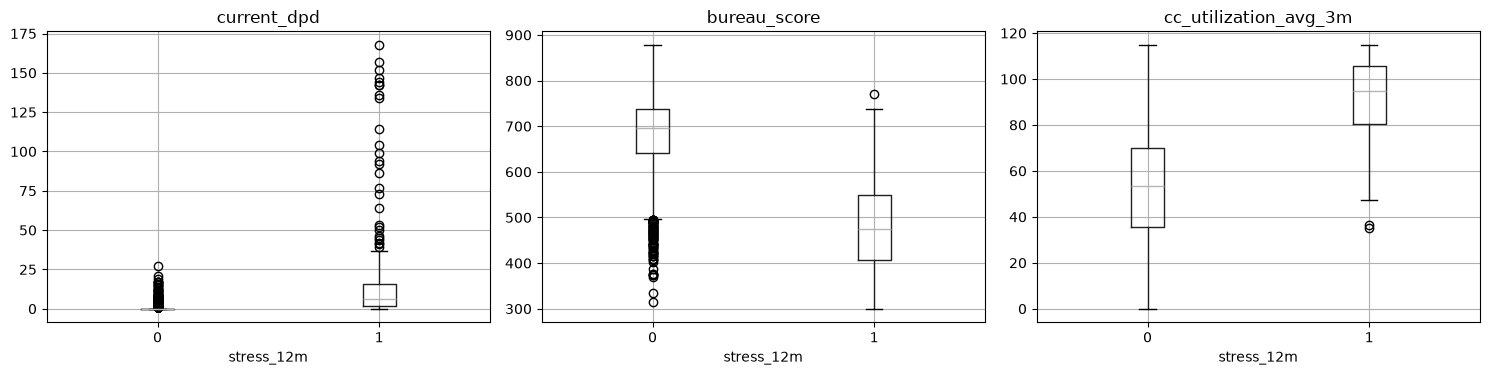

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
demo_df.boxplot(column='current_dpd', by='stress_12m', ax=axes[0])
demo_df.boxplot(column='bureau_score', by='stress_12m', ax=axes[1])
demo_df.boxplot(column='cc_utilization_avg_3m', by='stress_12m', ax=axes[2])
plt.suptitle('')
plt.tight_layout()
plt.show()

## Sample text remarks (positive vs negative signal mix)

In [5]:
for i, row in demo_df.sample(3, random_state=1).iterrows():
    print(f"Borrower {row['borrower_id']} (stress_12m={row['stress_12m']}):")
    print(' CAM:', row['cam_remarks'])
    print(' FI:', row['fi_remarks'])
    print(' RCU:', row['rcu_remarks'])
    print()

Borrower B100013 (stress_12m=0):
 CAM: financials in line with projections; cash flow stress visible; declining turnover trend observed.
 FI: stock levels found adequate; frequent promise to pay noted; shop found closed during visit.
 RCU: no adverse RCU observation.

Borrower B100350 (stress_12m=0):
 CAM: business running satisfactorily.
 FI: field investigation found no adverse observation.
 RCU: no linkage with other defaulting entities found.

Borrower B100370 (stress_12m=0):
 CAM: promoter diverting funds to group entity suspected; adequate liquidity maintained; cash flow stress visible.
 FI: unit operational with visible activity.
 RCU: no linkage with other defaulting entities found.



## Next step

Proceed to `02_feature_engineering.ipynb`, which operates on the full production dataset (`data/synthetic_msme_data.csv`) generated by the CLI script.